In [1]:
#Tugas 01
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('rounded_hours_student_scores.csv')
print(df.head())

   Hours  Scores
0    1.1      41
1    1.2      40
2    1.4      38
3    1.5      39
4    1.6      36


In [2]:
print(df.columns)

Index(['Hours', 'Scores'], dtype='str')


In [3]:
# X = waktu belajar
# y = score

X = df[['Hours']].values
y = df['Scores'].values

print("X:")
print(X[:5])

print("\ny:")
print(y[:5])

X:
[[1.1]
 [1.2]
 [1.4]
 [1.5]
 [1.6]]

y:
[41 40 38 39 36]


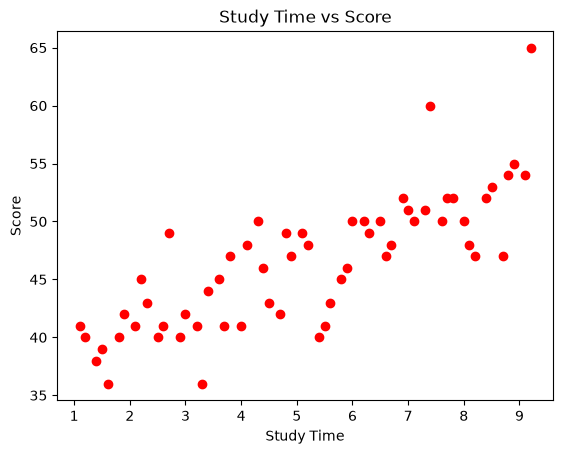

In [ ]:
plt.scatter(X, y, color='red')
plt.xlabel('Study Time')
plt.ylabel('Score')
plt.title('Study Time vs Score')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.87]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,36.46
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[15.83]


In [7]:
a = regressor.intercept_
b = regressor.coef_[0]
print("Estimated model intercept, a:", a)
print("Estimated model slope, b:", b)
print(f"ŷ = {a:.2f} + {b:.2f}x")

Estimated model intercept, a: 36.46097067904957
Estimated model slope, b: 1.8742157088578217
ŷ = 36.46 + 1.87x


In [8]:
# Memprediksi score pada data testing
y_pred = regressor.predict(X_test)
print("Hasil prediksi:")
print(y_pred)

Hasil prediksi:
[38.52260796 39.83455895 47.70626493 50.14274535 41.89619623 52.3918042
 46.95657865 50.89243164 41.52135309 53.14149049 50.33016692 51.45469635]


In [9]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
print("R-Square:", score)

R-Square: 0.5809502309078735


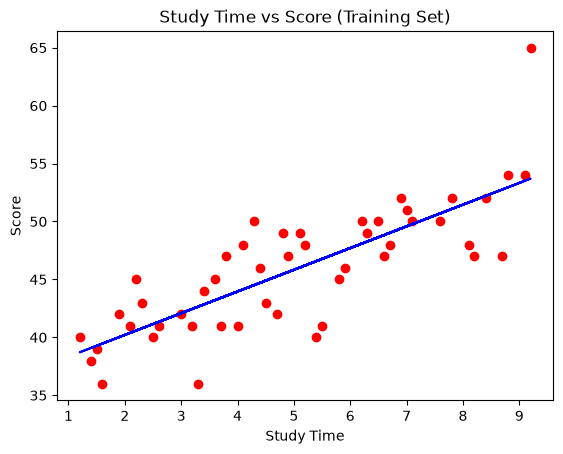

In [10]:
plt.scatter(X_train, y_train, color='red')
plt.plot(X_train, regressor.predict(X_train), color='blue')

plt.title('Study Time vs Score (Training Set)')
plt.xlabel('Study Time')
plt.ylabel('Score')

plt.show()

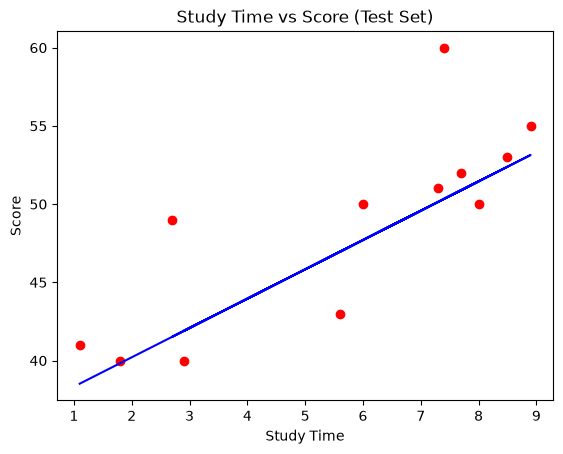

In [11]:
plt.scatter(X_test, y_test, color='red')
plt.plot(X_test, regressor.predict(X_test), color='blue')

plt.title('Study Time vs Score (Test Set)')
plt.xlabel('Study Time')
plt.ylabel('Score')

plt.show()

In [12]:
#Tugas 02
import pandas as pd
df2 = pd.read_csv('Marketing_Data.csv')
df2

,youtube,facebook,newspaper,sales
0,84.72,19.20,48.96,12.60
1,351.48,33.96,51.84,25.68
2,135.48,20.88,46.32,14.28
3,116.64,1.80,36.00,11.52
4,318.72,24.00,0.36,20.88
...,...,...,...,...
166,45.84,4.44,16.56,9.12
167,113.04,5.88,9.72,11.64
168,212.40,11.16,7.68,15.36
169,340.32,50.40,79.44,30.60


In [13]:
df2.head()

,youtube,facebook,newspaper,sales
0,84.72,19.20,48.96,12.60
1,351.48,33.96,51.84,25.68
2,135.48,20.88,46.32,14.28
3,116.64,1.80,36.00,11.52
4,318.72,24.00,0.36,20.88


In [14]:
X2 = df2.iloc[:, :-1]
y2 = df2.iloc[:, 3]

In [15]:
from sklearn.model_selection import train_test_split
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [16]:
from sklearn.linear_model import LinearRegression
regressor2 = LinearRegression()

In [17]:
regressor2.fit(X_train2, y_train2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0.04, 0.19,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['youtube','facebook','newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.703
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [ ]:
a2 = regressor2.intercept_
b2 = regressor2.coef_

print("Intercept (a) =", a2)
print("Koefisien =", b2)

Intercept (a) = 3.7030498901646
Koefisien = [ 4.41858407e-02  1.94481975e-01 -4.88341093e-05]


In [19]:
print("Persamaan Regresi:")

print(
    f"sales = {a2:.4f} + "
    f"({b2[0]:.4f} × youtube) + "
    f"({b2[1]:.4f} × facebook) + "
    f"({b2[2]:.4f} × newspaper)"
)

Persamaan Regresi:
sales = 3.7030 + (0.0442 × youtube) + (0.1945 × facebook) + (-0.0000 × newspaper)


In [20]:
y_pred2 = regressor2.predict(X_test2)

y_pred2

array([12.98143963, 25.0567515 , 18.23740714, 20.62856013, 11.58829542,
        8.56498386, 13.34769213, 23.17303975, 12.02633774, 24.95658385,
       10.22642185, 13.42592269, 13.98390345, 11.02921411, 20.75850022,
       26.45365807, 28.93272026, 21.7591148 , 21.250927  , 24.16369214,
       20.67745028,  9.84089667, 19.43433157, 18.23654615, 14.28836092,
       26.10738797, 20.88069217, 10.57749746, 12.21748717, 23.14056427,
        7.00528355,  8.46444339, 16.59917838, 21.84022174, 18.1370266 ])

In [21]:
from sklearn.metrics import r2_score
score2 = r2_score(y_test2, y_pred2)
print("R² Score =", score2)

R² Score = 0.872863085701216


In [22]:
hasil = pd.DataFrame({'Actual Sales': y_test2.values, 'Predicted Sales': y_pred2})
hasil

,Actual Sales,Predicted Sales
0,1.92,12.981440
1,26.04,25.056751
2,18.24,18.237407
3,20.52,20.628560
4,12.36,11.588295
5,10.44,8.564984
6,14.28,13.347692
7,23.52,23.173040
8,11.52,12.026338
9,24.96,24.956584
